## 1. Setup

Each 640x640 crop filename contains the original frame number and crop offset. YOLO detections are converted back into global 1920x1080 coordinates before tracking and line crossing.


In [1]:
import os
import re
import math
import warnings
from pathlib import Path
from collections import defaultdict

os.environ.setdefault("YOLO_CONFIG_DIR", str(Path.cwd().parent / ".ultralytics"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from ultralytics import YOLO

warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd()
TRAFFIC_ROOT = DATA_DIR / "TrafficProject"
IMAGE_DIR = TRAFFIC_ROOT / "train"
RESULTS_DIR = TRAFFIC_ROOT / "results"
V2_DIR = RESULTS_DIR / "task3_v2_line_crossing"
MODEL_PATH = RESULTS_DIR / "fine_tuned_artifacts" / "weights" / "best.pt"

V2_DIR.mkdir(parents=True, exist_ok=True)

assert MODEL_PATH.exists(), f"Missing fine-tuned model: {MODEL_PATH}"
assert IMAGE_DIR.exists(), f"Missing image directory: {IMAGE_DIR}"

FRAME_RE = re.compile(r"frame_(\d+)_y(\d+)_x(\d+)", re.IGNORECASE)
VEHICLE_CLASSES = {"Cars", "Bus_Truck", "Two_Wheeler"}

# Counting lines are in global 1920x1080 coordinates.
# Direction indicates the movement needed to count as entering the junction.
COUNTING_LINES = {
    "west_in": {"p1": (720, 560), "p2": (720, 730), "axis": "x", "direction": +1},
    "east_in": {"p1": (1220, 300), "p2": (1220, 520), "axis": "x", "direction": -1},
    "north_in": {"p1": (740, 360), "p2": (1040, 360), "axis": "y", "direction": +1},
    "south_in": {"p1": (920, 760), "p2": (1130, 760), "axis": "y", "direction": -1},
}

def parse_image_name(path):
    # Read the frame number and crop offset from one image filename.
    match = FRAME_RE.search(path.name)
    if match is None:
        return None
    return {
        "frame_id": int(match.group(1)),
        "crop_y": int(match.group(2)),
        "crop_x": int(match.group(3)),
        "path": path,
    }

records = []
for path in sorted(IMAGE_DIR.glob("*.jpg")):
    parsed = parse_image_name(path)
    if parsed:
        records.append(parsed)

image_df = pd.DataFrame(records).sort_values(["frame_id", "crop_y", "crop_x"]).reset_index(drop=True)
assert len(image_df) > 0, "No frame crops were parsed."

print(f"Parsed crop images: {len(image_df)}")
print(f"Unique frame ids: {image_df['frame_id'].nunique()}")
print(f"Frame range: {image_df['frame_id'].min()}..{image_df['frame_id'].max()}")


Parsed crop images: 4016
Unique frame ids: 816
Frame range: 1..831


## 2. Counting Lines

Each line is placed on an incoming road close to the junction. A vehicle is counted when its tracked center crosses the line in the correct direction.


Saved counting-line overlay: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_counting_lines_overlay.jpg


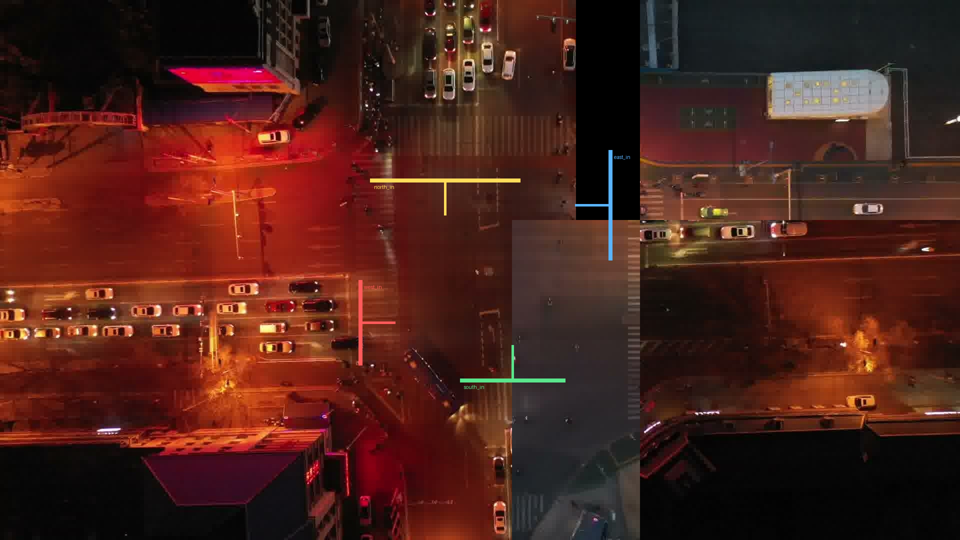

In [2]:
def representative_mosaic(frame_id=None):
    # Rebuild one approximate full-frame view from its crop tiles.
    if frame_id is None:
        frame_id = int(image_df.groupby("frame_id").size().sort_values(ascending=False).index[0])
    subset = image_df[image_df["frame_id"] == frame_id].drop_duplicates(["crop_y", "crop_x"])
    canvas = Image.new("RGB", (1920, 1080), "black")
    for _, row in subset.iterrows():
        crop = Image.open(row["path"]).convert("RGB")
        canvas.paste(crop, (int(row["crop_x"]), int(row["crop_y"])))
    return frame_id, canvas

colors = {
    "west_in": (255, 90, 90),
    "east_in": (90, 180, 255),
    "north_in": (255, 220, 90),
    "south_in": (90, 230, 140),
}

line_frame_id, mosaic = representative_mosaic()
overlay = mosaic.copy()
draw = ImageDraw.Draw(overlay)
for name, line in COUNTING_LINES.items():
    p1, p2 = line["p1"], line["p2"]
    draw.line([p1, p2], fill=colors[name], width=8)
    draw.text((p1[0] + 8, p1[1] + 8), name, fill=colors[name])
    if line["axis"] == "x":
        arrow_y = (p1[1] + p2[1]) // 2
        arrow_x = p1[0]
        end_x = arrow_x + 70 * line["direction"]
        draw.line([(arrow_x, arrow_y), (end_x, arrow_y)], fill=colors[name], width=5)
    else:
        arrow_x = (p1[0] + p2[0]) // 2
        arrow_y = p1[1]
        end_y = arrow_y + 70 * line["direction"]
        draw.line([(arrow_x, arrow_y), (arrow_x, end_y)], fill=colors[name], width=5)

overlay_path = V2_DIR / "task3_v2_counting_lines_overlay.jpg"
overlay.save(overlay_path, quality=95)
print(f"Saved counting-line overlay: {overlay_path}")
display(overlay.resize((960, 540)))


## 3. Run Detector and Merge Crop Duplicates

The detector is run on all crops. Detections are translated to full-frame coordinates and duplicate boxes from overlapping crops are removed per frame and class with IoU NMS.


In [3]:
def iou_xyxy(a, b):
    # Compute overlap between two bounding boxes in x1,y1,x2,y2 format.
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return 0.0 if union <= 0 else inter / union

def nms_by_frame_class(detections, iou_threshold=0.5):
    # Remove duplicate detections from overlapping crops for each frame/class.
    grouped = defaultdict(list)
    for det in detections:
        grouped[(det["frame_id"], det["class_name"])].append(det)

    kept = []
    for group in grouped.values():
        group = sorted(group, key=lambda item: item["confidence"], reverse=True)
        while group:
            current = group.pop(0)
            kept.append(current)
            group = [item for item in group if iou_xyxy(current["box"], item["box"]) < iou_threshold]
    return kept

def chunks(items, size):
    # Yield small batches so YOLO inference does not run out of GPU memory.
    for start in range(0, len(items), size):
        yield items[start:start + size]

model = YOLO(str(MODEL_PATH))
paths = [str(path) for path in image_df["path"].tolist()]
metadata_by_path = {str(Path(row["path"]).resolve()): row for _, row in image_df.iterrows()}

raw_detections = []
chunk_size = 64
for chunk_index, path_chunk in enumerate(chunks(paths, chunk_size), start=1):
    print(f"Predicting chunk {chunk_index}/{math.ceil(len(paths) / chunk_size)}", end="\r")
    for result in model.predict(source=path_chunk, imgsz=640, conf=0.25, batch=8, stream=True, verbose=False):
        row = metadata_by_path[str(Path(result.path).resolve())]
        frame_id = int(row["frame_id"])
        ox, oy = float(row["crop_x"]), float(row["crop_y"])

        if result.boxes is None:
            continue

        for box, cls_id, conf in zip(result.boxes.xyxy.tolist(), result.boxes.cls.tolist(), result.boxes.conf.tolist()):
            class_name = model.names[int(cls_id)]
            if class_name not in VEHICLE_CLASSES:
                continue
            # Move the crop-local YOLO box back into full-intersection coordinates.
            gx1, gy1 = float(box[0]) + ox, float(box[1]) + oy
            gx2, gy2 = float(box[2]) + ox, float(box[3]) + oy
            raw_detections.append({
                "frame_id": frame_id,
                "class_name": class_name,
                "confidence": float(conf),
                "box": [gx1, gy1, gx2, gy2],
                "cx": (gx1 + gx2) / 2.0,
                "cy": (gy1 + gy2) / 2.0,
            })

detections = nms_by_frame_class(raw_detections, iou_threshold=0.5)
detections_df = pd.DataFrame([
    {
        "frame_id": d["frame_id"],
        "class_name": d["class_name"],
        "confidence": d["confidence"],
        "x1": d["box"][0],
        "y1": d["box"][1],
        "x2": d["box"][2],
        "y2": d["box"][3],
        "cx": d["cx"],
        "cy": d["cy"],
    }
    for d in detections
])
detections_path = V2_DIR / "task3_v2_global_detections.csv"
detections_df.to_csv(detections_path, index=False)
print()
print(f"Raw detections: {len(raw_detections)}")
print(f"Detections after NMS: {len(detections_df)}")
print(f"Saved global detections: {detections_path}")



Raw detections: 107682
Detections after NMS: 82988
Saved global detections: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_global_detections.csv


## 4. Track Centers and Count Line Crossings

A simple centroid tracker links detections between neighboring frames. When a track segment crosses a counting line in the incoming direction, that frame receives one count for that road.


In [4]:
def crosses_line(previous_center, current_center, line):
    # Return True when a tracked center moves across a counting line inward.
    px, py = previous_center
    cx, cy = current_center
    p1, p2 = line["p1"], line["p2"]

    if line["axis"] == "x":
        line_x = p1[0]
        y_min, y_max = sorted([p1[1], p2[1]])
        if line["direction"] > 0:
            crossed = px < line_x <= cx
        else:
            crossed = px > line_x >= cx
        if not crossed:
            return False
        # Approximate crossing y by requiring either segment endpoint near the line span.
        return (y_min <= py <= y_max) or (y_min <= cy <= y_max)

    line_y = p1[1]
    x_min, x_max = sorted([p1[0], p2[0]])
    if line["direction"] > 0:
        crossed = py < line_y <= cy
    else:
        crossed = py > line_y >= cy
    if not crossed:
        return False
    return (x_min <= px <= x_max) or (x_min <= cx <= x_max)

detections_by_frame = {
    int(frame_id): group.sort_values("confidence", ascending=False).to_dict("records")
    for frame_id, group in detections_df.groupby("frame_id")
}

# The tracker links detections between nearby frames by center distance.
max_match_distance = 170.0
max_missed_frames = 2
next_track_id = 1
tracks = {}
crossing_rows = []
track_rows = []

for frame_id in sorted(image_df["frame_id"].unique()):
    frame_dets = detections_by_frame.get(int(frame_id), [])
    frame_counts = {"frame_id": int(frame_id), **{name: 0 for name in COUNTING_LINES}}

    # Keep recently seen tracks alive for a couple of missed frames.
    active_ids = [
        tid for tid, track in tracks.items()
        if frame_id - track["last_frame"] <= max_missed_frames + 1
    ]
    unmatched_tracks = set(active_ids)
    unmatched_dets = set(range(len(frame_dets)))
    candidate_matches = []

    # Build possible detection-track matches, then greedily keep nearest ones.
    for tid in active_ids:
        track = tracks[tid]
        for det_index, det in enumerate(frame_dets):
            if det["class_name"] != track["class_name"]:
                continue
            dist = math.hypot(det["cx"] - track["center"][0], det["cy"] - track["center"][1])
            if dist <= max_match_distance:
                candidate_matches.append((dist, tid, det_index))

    for _, tid, det_index in sorted(candidate_matches):
        if tid not in unmatched_tracks or det_index not in unmatched_dets:
            continue
        det = frame_dets[det_index]
        previous_center = tracks[tid]["center"]
        current_center = (float(det["cx"]), float(det["cy"]))

        # Count a road only once per track so the same vehicle is not double-counted.
        for direction, line in COUNTING_LINES.items():
            if direction in tracks[tid]["counted_directions"]:
                continue
            if crosses_line(previous_center, current_center, line):
                frame_counts[direction] += 1
                tracks[tid]["counted_directions"].add(direction)

        tracks[tid].update({
            "center": current_center,
            "last_frame": int(frame_id),
            "confidence": float(det["confidence"]),
        })
        track_rows.append({
            "frame_id": int(frame_id),
            "track_id": tid,
            "class_name": det["class_name"],
            "cx": current_center[0],
            "cy": current_center[1],
        })
        unmatched_tracks.remove(tid)
        unmatched_dets.remove(det_index)

    # Unmatched detections start new vehicle tracks.
    for det_index in unmatched_dets:
        det = frame_dets[det_index]
        tracks[next_track_id] = {
            "class_name": det["class_name"],
            "center": (float(det["cx"]), float(det["cy"])),
            "last_frame": int(frame_id),
            "confidence": float(det["confidence"]),
            "counted_directions": set(),
        }
        track_rows.append({
            "frame_id": int(frame_id),
            "track_id": next_track_id,
            "class_name": det["class_name"],
            "cx": float(det["cx"]),
            "cy": float(det["cy"]),
        })
        next_track_id += 1

    frame_counts["total_flow"] = sum(frame_counts[name] for name in COUNTING_LINES)
    crossing_rows.append(frame_counts)

flow_df = pd.DataFrame(crossing_rows)
tracks_df = pd.DataFrame(track_rows)

flow_path = V2_DIR / "task3_v2_line_crossing_timeseries.csv"
tracks_path = V2_DIR / "task3_v2_tracks.csv"
flow_df.to_csv(flow_path, index=False)
tracks_df.to_csv(tracks_path, index=False)

print(f"Saved line-crossing time series: {flow_path}")
print(f"Saved tracks: {tracks_path}")
print("Total crossings by direction:")
print(flow_df[[*COUNTING_LINES.keys(), "total_flow"]].sum())
display(flow_df.head())


Saved line-crossing time series: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_line_crossing_timeseries.csv
Saved tracks: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_tracks.csv
Total crossings by direction:
west_in        74
east_in       122
north_in       89
south_in       59
total_flow    344
dtype: int64


,frame_id,west_in,east_in,north_in,south_in,total_flow
0,1,0,0,0,0,0
1,2,0,0,0,0,0
2,5,0,0,0,0,0
3,6,0,0,0,0,0
4,7,1,0,0,0,1


## 5. Traffic Pattern Analysis

The line-crossing counts are sparse because a vehicle is counted only at the moment its tracked center crosses an incoming line. The frame-level counts are also aggregated into 10-second bins for clearer forecasting.


Saved frame-level line-crossing plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_line_crossing_timeseries.png


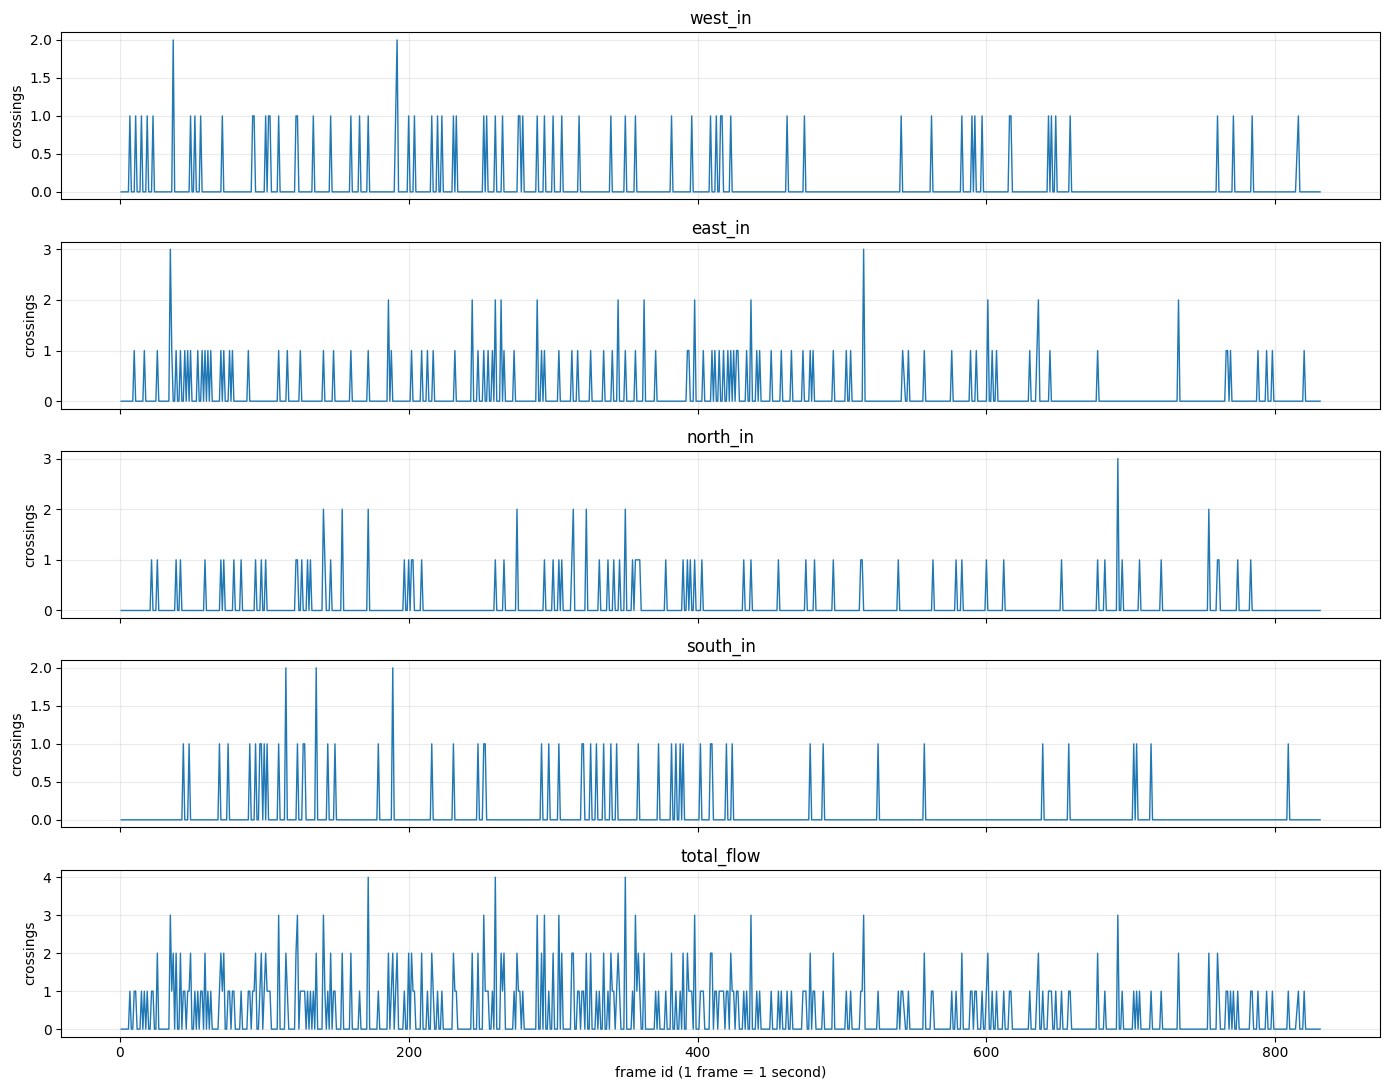

Saved 10-second aggregated series: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_line_crossing_timeseries_10sec.csv


,west_in,east_in,north_in,south_in,total_flow
time_bin_10sec,,,,,
0,2,1,0,0,3
1,2,1,1,0,4
2,1,1,1,0,3
3,2,6,2,0,10
4,2,3,0,2,7


In [5]:
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
for ax, column in zip(axes, [*COUNTING_LINES.keys(), "total_flow"]):
    ax.plot(flow_df["frame_id"], flow_df[column], linewidth=1)
    ax.set_title(column)
    ax.set_ylabel("crossings")
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("frame id (1 frame = 1 second)")
plt.tight_layout()
flow_plot_path = V2_DIR / "task3_v2_line_crossing_timeseries.png"
fig.savefig(flow_plot_path, dpi=150)
print(f"Saved frame-level line-crossing plot: {flow_plot_path}")
plt.show()

agg = flow_df.copy()
agg["time_second"] = np.arange(len(agg))
agg["bin_10sec"] = agg["time_second"] // 10
agg_df = agg.groupby("bin_10sec")[[*COUNTING_LINES.keys(), "total_flow"]].sum()
agg_df.index.name = "time_bin_10sec"
agg_path = V2_DIR / "task3_v2_line_crossing_timeseries_10sec.csv"
agg_df.to_csv(agg_path)
print(f"Saved 10-second aggregated series: {agg_path}")
display(agg_df.head())


## 6. Forecasting and Baseline Evaluation

SARIMAX is compared with a simple naive persistence baseline. The train/test split uses the first 80 percent for training and the last 20 percent for testing. The future forecast horizon is one hour. Since the source video is only about 13.6 minutes long, the one-hour forecast should still be treated as an extrapolation.


In [6]:
def naive_persistence_forecast(train, test):
    # Simple baseline: predict that the next value equals the latest value.
    history = list(train)
    predictions = []
    for actual in test:
        predictions.append(history[-1] if history else 0.0)
        history.append(actual)
    return np.asarray(predictions, dtype=float)

def fit_sarimax_forecast(train, steps):
    # Fit a small SARIMAX/ARIMA model and forecast the requested steps.
    orders = [(1, 0, 1), (1, 0, 0), (0, 0, 1)]
    last_error = None
    for order in orders:
        try:
            model = SARIMAX(
                train,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            result = model.fit(disp=False, maxiter=200)
            forecast = np.asarray(result.forecast(steps=steps), dtype=float)
            return np.maximum(forecast, 0.0), order
        except Exception as exc:
            last_error = exc
    print(f"SARIMAX fallback used: {last_error}")
    return np.repeat(float(train[-1]) if len(train) else 0.0, steps), "fallback_last_value"

def metric_row(series_name, model_name, y_true, y_pred, order=None):
    # Calculate error metrics for one forecast series.
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    nonzero = y_true != 0
    mape = np.nan
    if nonzero.sum() >= max(3, int(0.2 * len(y_true))):
        mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100.0
    return {
        "series": series_name,
        "model": model_name,
        "order": str(order) if order is not None else "",
        "mae": mae,
        "rmse": rmse,
        "mape_percent": mape,
    }

forecast_columns = [*COUNTING_LINES.keys(), "total_flow"]
train_size = int(len(agg_df) * 0.8)
# One hour = 3600 seconds = 360 ten-second bins.
horizon = 360
metric_rows = []
forecast_outputs = {}

for column in forecast_columns:
    series = agg_df[column].astype(float).to_numpy()
    train = series[:train_size]
    test = series[train_size:]
    sarimax_test, order = fit_sarimax_forecast(train, len(test))
    naive_test = naive_persistence_forecast(train, test)

    metric_rows.append(metric_row(column, "SARIMAX", test, sarimax_test, order))
    metric_rows.append(metric_row(column, "Naive persistence", test, naive_test))

    future_sarimax, future_order = fit_sarimax_forecast(series, horizon)
    future_naive = np.repeat(float(series[-1]), horizon)
    forecast_outputs[column] = {
        "series": series,
        "sarimax_test": sarimax_test,
        "naive_test": naive_test,
        "future_sarimax": future_sarimax,
        "future_naive": future_naive,
        "order": future_order,
    }

metrics_df = pd.DataFrame(metric_rows)
metrics_path = V2_DIR / "task3_v2_forecast_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved forecast metrics: {metrics_path}")
display(metrics_df)


Saved forecast metrics: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_forecast_metrics.csv


,series,model,order,mae,rmse,mape_percent
0,west_in,SARIMAX,"(1, 0, 1)",0.765616,0.870280,2.008054
1,west_in,Naive persistence,,0.470588,0.766965,75.000000
2,east_in,SARIMAX,"(1, 0, 1)",1.342845,1.450803,47.489414
3,east_in,Naive persistence,,1.058824,1.455214,91.666667
4,north_in,SARIMAX,"(1, 0, 1)",1.059299,1.331862,30.077128
5,north_in,Naive persistence,,1.352941,1.925067,110.714286
6,south_in,SARIMAX,"(1, 0, 1)",0.814399,0.857140,24.890209
7,south_in,Naive persistence,,0.411765,0.727607,100.000000
8,total_flow,SARIMAX,"(1, 0, 1)",2.190116,2.483828,128.924882
9,total_flow,Naive persistence,,1.647059,2.114377,66.666667


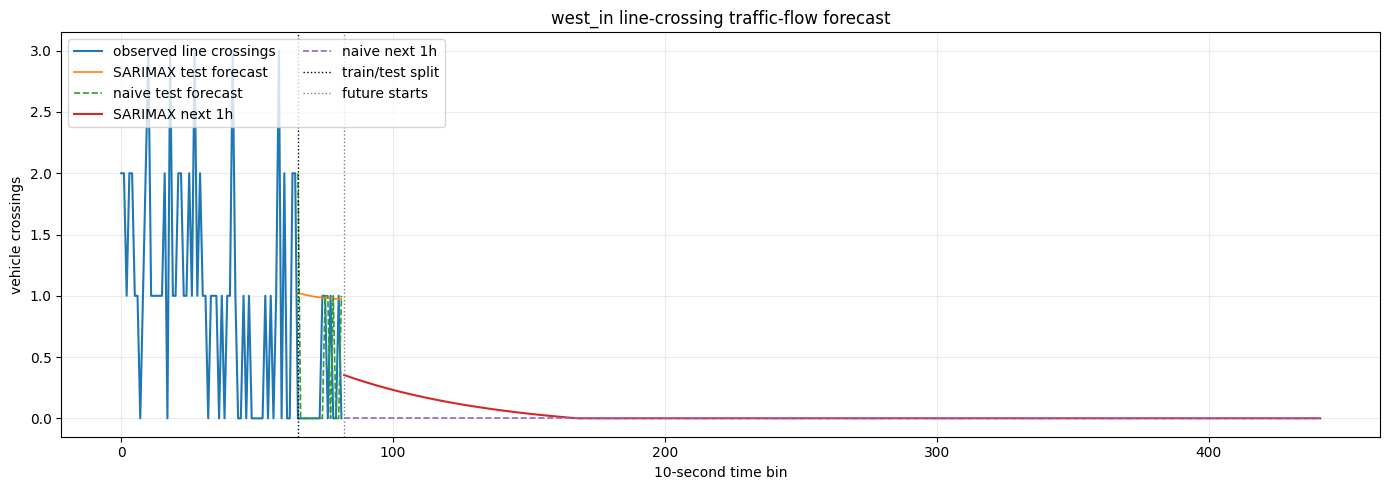

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_forecast_plot_west_in.png


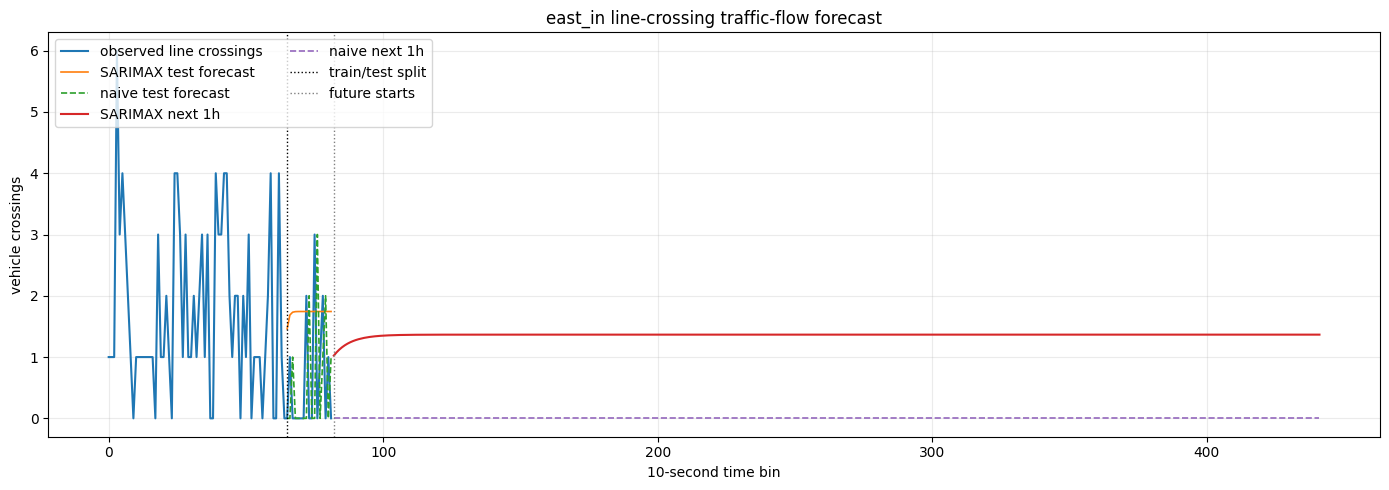

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_forecast_plot_east_in.png


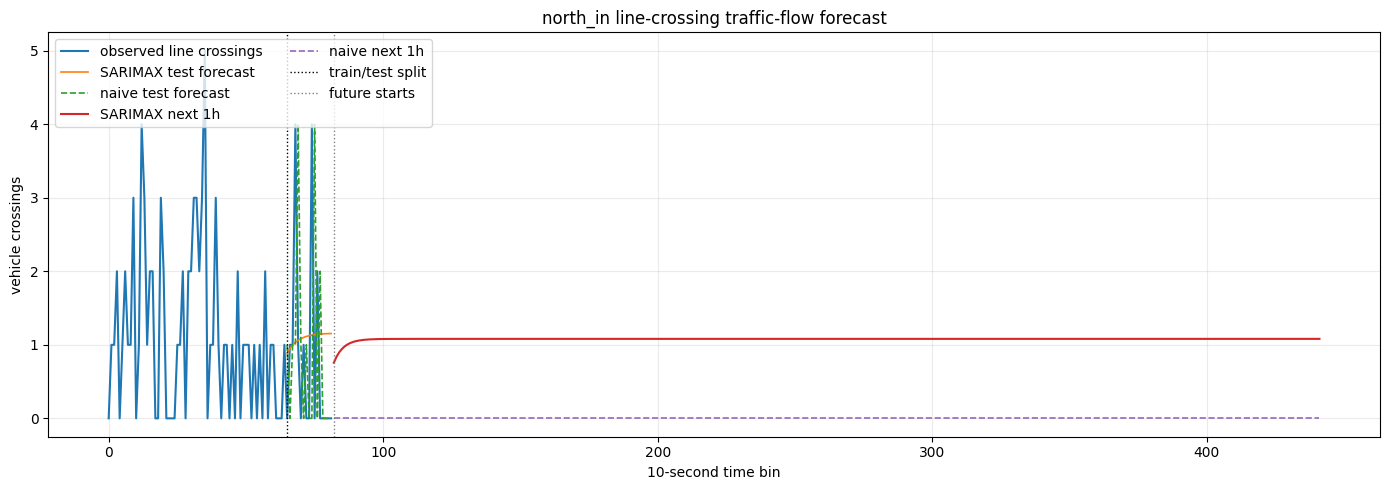

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_forecast_plot_north_in.png


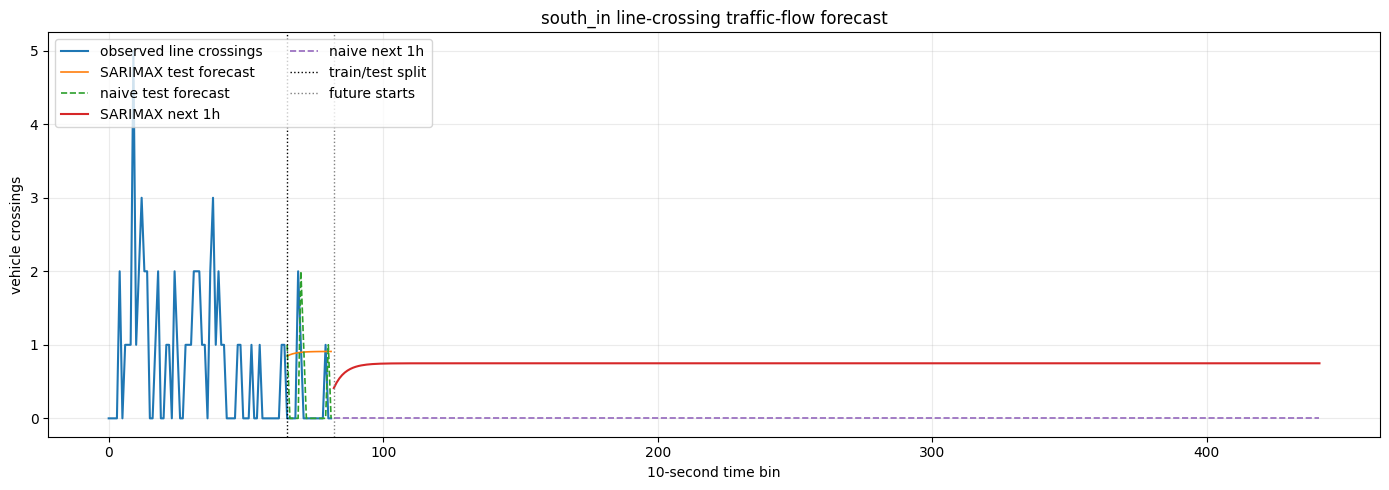

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_forecast_plot_south_in.png


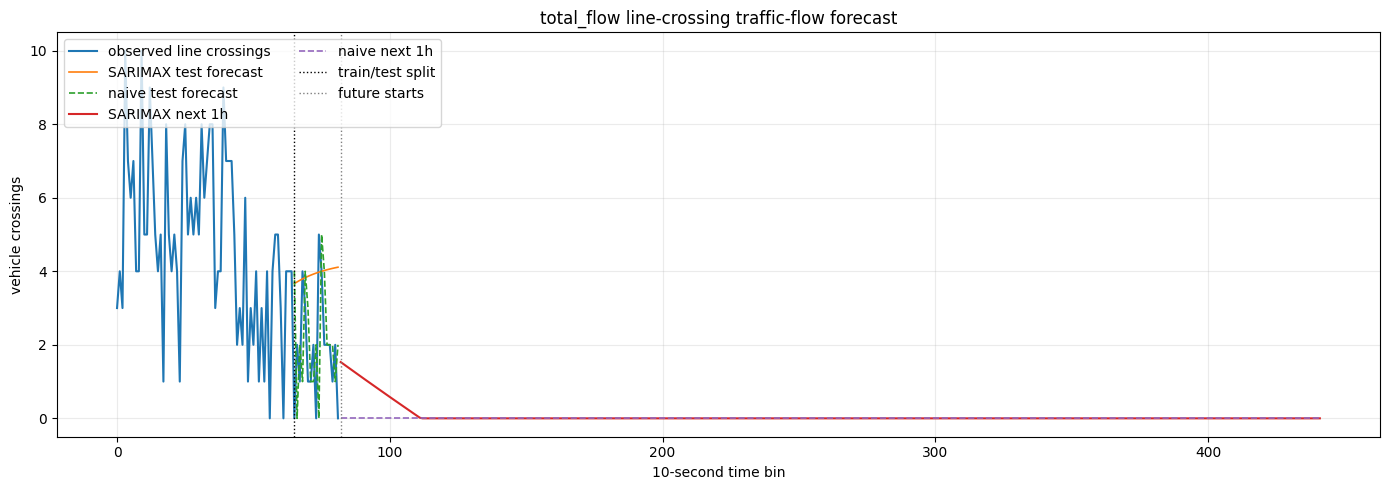

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_v2_line_crossing\task3_v2_forecast_plot_total_flow.png


In [7]:
def plot_forecast(column):
    # Plot observed crossings, test predictions, and the one-hour forecast.
    out = forecast_outputs[column]
    series = out["series"]
    x = np.arange(len(series))
    test_x = np.arange(train_size, len(series))
    future_x = np.arange(len(series), len(series) + horizon)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(x, series, label="observed line crossings", linewidth=1.5)
    ax.plot(test_x, out["sarimax_test"], label="SARIMAX test forecast", linewidth=1.2)
    ax.plot(test_x, out["naive_test"], label="naive test forecast", linestyle="--", linewidth=1.2)
    ax.plot(future_x, out["future_sarimax"], label="SARIMAX next 1h", linewidth=1.5)
    ax.plot(future_x, out["future_naive"], label="naive next 1h", linestyle="--", linewidth=1.2)
    ax.axvline(train_size, color="black", linestyle=":", linewidth=1, label="train/test split")
    ax.axvline(len(series), color="gray", linestyle=":", linewidth=1, label="future starts")
    ax.set_title(f"{column} line-crossing traffic-flow forecast")
    ax.set_xlabel("10-second time bin")
    ax.set_ylabel("vehicle crossings")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", ncols=2)
    plt.tight_layout()
    output_path = V2_DIR / f"task3_v2_forecast_plot_{column}.png"
    fig.savefig(output_path, dpi=150)
    plt.show()
    print(f"Saved forecast plot: {output_path}")

for column in forecast_columns:
    plot_forecast(column)
